# Estimate Demand System — Tanzania (Hicks)

## EEP 153 — Project 3

**Deliverable:** Counterfactual Experiments (C)

**Data Source:** [Tanzania - Hicks Google Sheet](https://docs.google.com/spreadsheets/d/1LRe2bjhimuwrTXU8MpmQFH02MJegNRpmwNkY9T3HGqA/edit)

**Survey Waves:** 2019-20 and 2020-21

---

In [56]:
#Importing
import pandas as pd
import numpy as np
from datascience import *
import matplotlib.pyplot as plt
import warnings 
import seaborn as sns
warnings.filterwarnings('ignore')
%matplotlib inline

## Functions

- Function that calculate the total nutrient for each household
- Function that calculate the avergae nutrient for each person in the household
- Function that calculate how many people meeting the RDA requirement

In [5]:
#Reading files
FCT = pd.read_csv('Tanzania - Hicks - FCT.csv')
Household_characteristics = pd.read_csv('Tanzania - Household Characteristics.csv')
Nutrient_requirement = pd.read_csv('Tanzania - Hicks - RDA.csv')

#Reading files for 2019 - 2020
Food_Expenditure_1920_perday = pd.read_csv('Tanzania - Food Expenditures (2019-20).csv')
Food_Expenditure_1920_perday["Expenditure"] = Food_Expenditure_1920_perday["Expenditure"] / 30
Food_Prices_1920 = pd.read_csv('Tanzania - Food Prices (2019-20).csv').dropna(how='any')
Household_characteristics_1920 = Household_characteristics[Household_characteristics['t'] == "2019-20"]

#Reading files for 2020 - 2021
Food_Expenditure_2021_perday = pd.read_csv('Tanzania - Food Expenditures (2020-21).csv')
Food_Expenditure_2021_perday["Expenditure"] = Food_Expenditure_2021_perday["Expenditure"] / 30
Food_Prices_2021 = pd.read_csv('Tanzania - Food Prices (2020-21).csv').dropna(how='any')
Household_characteristics_2021 = Household_characteristics[Household_characteristics['t'] == "2020-21"]

#Mutiplying the expenditure
def change_price(df_expenditure, multiple):
    df_expenditure = df_expenditure.copy()
    df_expenditure["Expenditure"] = df_expenditure["Expenditure"] * multiple
    return df_expenditure



#Total nutrient for each household
def ttl_nutrient_household(FCT, Household_Characteristic, Expenditure, Food_Price):
    
    #Merging datasets
    merged_df = pd.merge(Household_Characteristic, Expenditure.drop(columns=['t', 'm']), on='i', how='inner')
    merged_df = pd.merge(merged_df, Food_Price, on=["j","m"],how = "left")
    merged_df["Quantity of Food"] = merged_df["Expenditure"] / merged_df["Price"]
    merged_df = merged_df.drop_duplicates(subset=['i', 'j'], keep='first')
    merged_df = merged_df[["i", "m","log HSize", "j","u","Quantity of Food"]]
    merged_df = pd.merge(merged_df, FCT, on='j', how='left')
    
    df_total_nutrients_per_household = merged_df[[
        "i",
        "Quantity of Food",
        "Energy",
        "Protein",
        "Vitamin A",
        "Vitamin D",
        "Vitamin E",
        "Vitamin C",
        "Vitamin B-6",
        "Vitamin B-12",
        "Calcium",
        "Magnesium",
        "Iron",
        "Zinc",
        "Fiber"
    ]]
    
    nutrient_cols = [
        "Energy", "Protein", "Vitamin A", "Vitamin D", "Vitamin E",
        "Vitamin C", "Vitamin B-6", "Vitamin B-12",
        "Calcium", "Magnesium", "Iron", "Zinc", "Fiber"
    ]
    
    #Multiplying nutrients by quantity
    df_total_nutrients_per_household [nutrient_cols] = df_total_nutrients_per_household [nutrient_cols].multiply(df_total_nutrients_per_household ["Quantity of Food"], axis=0)
    
    #Grouping individuals
    df_total_nutrients_per_household = df_total_nutrients_per_household.groupby("i")[nutrient_cols].sum().reset_index()[["i"]+nutrient_cols]
    
    return df_total_nutrients_per_household




#Average nutrient for each person in the household
def avg_nutrient_household(FCT, Household_Characteristic, Expenditure, Food_Price):
    ttl = ttl_nutrient_household(FCT, Household_Characteristic, Expenditure, Food_Price)
    ttl_w_household = pd.merge(ttl, Household_Characteristic[["i","log HSize"]], on=["i"], how="left")

    #Create HSize from log HSize
    ttl_w_household["HSize"] = np.exp(
        ttl_w_household["log HSize"]
    )

    #Drop the old column
    ttl_w_household = ttl_w_household.drop(
        columns=["log HSize"]
    )

    nutrient_cols = [
    "Energy", "Protein", "Vitamin A", "Vitamin D", "Vitamin E",
    "Vitamin C", "Vitamin B-6", "Vitamin B-12",
    "Calcium", "Magnesium", "Iron", "Zinc", "Fiber"
    ]

    # divide each nutrient by household size
    ttl_w_household.loc[:, nutrient_cols] = (
        ttl_w_household[nutrient_cols]
        .div(ttl_w_household["HSize"], axis=0)
    )

    return ttl_w_household



#Calculate the total people who meet the nutrition requirement
def num_meet_requirement(FCT, Household_Characteristic, Expenditure, Food_Price, Requirement):
    ttl = ttl_nutrient_household(FCT, Household_Characteristic, Expenditure, Food_Price)
    avg = avg_nutrient_household(FCT, Household_Characteristic, Expenditure, Food_Price)
    merged_df = pd.merge(avg, Household_Characteristic, on=["i"], how="left")

    nutrient_cols = [
        "Energy", "Protein", "Vitamin A", "Vitamin D", "Vitamin E",
        "Vitamin C", "Vitamin B-6", "Vitamin B-12",
        "Calcium", "Magnesium", "Iron", "Zinc", "Fiber"
    ]

    demo_cols = [
    "Females 09-13", "Males 14-18", "Females 14-18",
    "Males 19-30", "Females 19-30",
    "Males 31-50", "Females 31-50",
    "Males 51-99", "Females 51-99"
    ]

    def expand_household(row):
        people = []
        for col in demo_cols:
            count = int(row[col])
            people.extend([col] * count)
        return people

    # Add new column to dataframe
    merged_df["household_list"] = merged_df.apply(expand_household, axis=1)

    meet_requirement = []
    
    for i in range(len(merged_df)):
        count = 0
        meet = True
        household_lst = merged_df.iloc[i][-1]
        for j in household_lst:
            for k in range(len(Nutrient_requirement[j])):
                if Nutrient_requirement[j][k] < merged_df.iloc[i][1+k]:
                    continue
                else:
                    meet = False
                    break
            if meet:
                count += 1
        meet_requirement.append(count)

    merged_df["meet_requirement"] = meet_requirement

    #Create HSize from log HSize
    merged_df["HSize"] = np.exp(
        merged_df["log HSize"]
    )

    #Drop the old column
    merged_df = merged_df.drop(
        columns=["log HSize"]
    )
        
    return merged_df



original_1920 = num_meet_requirement(FCT, Household_characteristics_1920, Food_Expenditure_1920_perday, Food_Prices_1920, Nutrient_requirement)[['i', 'meet_requirement', "HSize"]]
original_1920

,i,meet_requirement,HSize
0,0001-001-001,0,2.0
1,0001-001-003,0,1.0
2,0001-001-004,0,1.0
3,0001-004-001,0,3.0
4,0001-004-002,0,1.0
...,...,...,...
1105,0856-001-001,0,11.0
1106,0856-001-003,0,7.0
1107,0857-001-001,0,8.0
1108,0858-001-001,0,3.0


In [6]:
avg_nutrient_household(FCT, Household_characteristics_2021, Food_Expenditure_2021_perday, Food_Prices_2021)

,i,Energy,Protein,Vitamin A,Vitamin D,Vitamin E,Vitamin C,Vitamin B-6,Vitamin B-12,Calcium,Magnesium,Iron,Zinc,Fiber,HSize
0,1009-001-01,501.475944,13.723874,369.744199,0.231311,0.616489,5.670857,0.275714,0.726141,141.921032,68.885219,3.660018,1.799179,4.097891,4.0
1,1025-001-02,1254.804919,28.443408,489.045910,0.217740,2.292807,16.269810,0.830326,0.180339,132.391055,244.103740,9.262341,4.824141,17.335201,1.0
2,1039-001-01,445.722465,10.576117,69.145011,0.387654,0.405808,1.445973,0.199844,0.035535,29.073901,80.339324,2.836734,1.761313,4.824262,5.0
3,1078-001-01,285.973944,6.340658,48.048374,0.270683,1.806364,15.962795,0.317524,0.160893,60.175748,54.149406,1.576709,0.864919,4.477359,7.0
4,1102-001-01,164.975912,2.606020,33.741491,0.000000,0.280473,0.357707,0.073062,0.063504,25.354832,32.587638,0.877119,0.451848,1.620304,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401,9760-001-99,420.378078,7.888224,106.529279,0.000000,0.483085,16.066739,0.378720,0.000000,40.798665,89.434869,3.652903,1.875566,5.094968,4.0
402,9772-001-99,242.727056,5.345603,19.598728,0.620247,0.429935,4.231646,0.163213,0.056856,12.045029,55.984649,1.458433,0.868330,2.947743,5.0
403,9784-001-99,228.578790,3.953129,129.035744,0.174444,0.564622,14.445520,0.189265,0.015991,35.668791,62.261986,1.952370,0.887525,3.655825,4.0
404,9796-001-99,297.422086,9.175536,102.604670,1.860740,0.801924,1.171392,0.245244,0.170568,28.567215,96.467774,2.493763,1.309201,4.284834,5.0


In [7]:
ttl_nutrient_household(FCT, Household_characteristics_1920, Food_Expenditure_1920_perday, Food_Prices_1920)

,i,Energy,Protein,Vitamin A,Vitamin D,Vitamin E,Vitamin C,Vitamin B-6,Vitamin B-12,Calcium,Magnesium,Iron,Zinc,Fiber
0,0001-001-001,1036.807274,29.456364,756.192889,0.000000,1.117285,23.595698,0.782578,0.091632,746.348648,158.790587,9.857971,4.170283,33.510677
1,0001-001-003,909.286460,24.596105,672.084749,0.525002,1.304771,21.137539,0.750967,0.459935,486.829630,173.679192,9.440993,4.364633,23.808637
2,0001-001-004,1091.409211,31.139540,781.871890,3.365833,2.573921,46.984595,0.980690,1.069261,122.577787,237.957683,7.815999,4.981592,11.693104
3,0001-004-001,1754.973914,39.851203,1439.905134,0.758337,4.895274,22.073827,0.953490,0.723752,701.493343,235.053169,9.966261,5.058403,29.894631
4,0001-004-002,509.620763,9.636940,194.990021,0.110772,0.325313,2.773496,0.315806,0.000000,384.721206,55.221991,4.294988,1.727958,17.836484
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1105,0856-001-001,1381.269191,20.090105,613.667433,6.339495,0.865551,16.025382,0.247093,0.581120,277.990944,86.086166,2.466680,1.711984,31.079758
1106,0856-001-003,1592.878892,37.162850,23.241955,6.339495,1.249582,11.112151,0.668035,0.581120,101.172897,181.635035,3.857244,3.562731,13.612697
1107,0857-001-001,2092.133926,52.674288,147.637253,9.509242,3.825125,30.267473,1.190083,1.192250,449.412037,270.472217,7.954650,5.474066,36.059831
1108,0858-001-001,1255.937964,34.530602,1106.685152,2.103646,3.571761,15.029817,1.051756,0.192834,227.876047,438.749193,14.193218,6.497911,22.732474


## Graph 1 and 2. Graph of Multiple of Expenditure vs Num of Meeting Requirement for 2019-2020 and 2020-2021

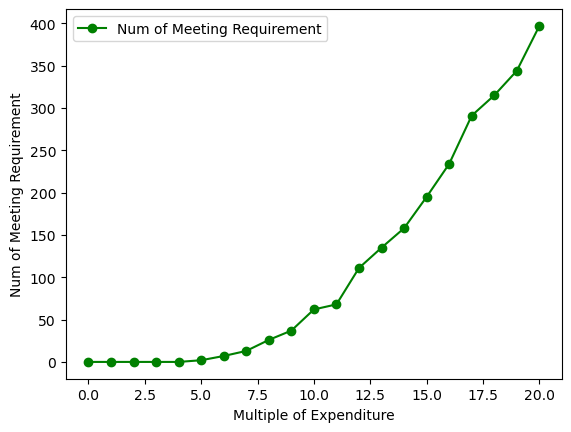

Total Number of People in the Dataset:  5434.0


In [8]:
def graph_meeting_nutrients(FCT, Household_Characteristic, Expenditure, Food_Price, Requirement):
    
    multiples_of_expenditures = list(range(21))
    ttl_meet_requirement = []
    for i in multiples_of_expenditures:
        current = num_meet_requirement(FCT, Household_Characteristic, change_price(Expenditure, i), Food_Price, Requirement)
        ttl_meet_requirement.append(sum(current['meet_requirement']))

    df = pd.DataFrame({
        "Multiple of Expenditure": multiples_of_expenditures,
        "Num of Meeting Requirement": ttl_meet_requirement
        })
    
    df.plot(x="Multiple of Expenditure", y="Num of Meeting Requirement", color="green", marker='o')
    plt.xlabel("Multiple of Expenditure")
    plt.ylabel("Num of Meeting Requirement")
    plt.show()
    print("Total Number of People in the Dataset: " , round(sum(avg_nutrient_household(FCT, Household_Characteristic, Expenditure, Food_Price)["HSize"]),0))

graph_meeting_nutrients(FCT, Household_characteristics_1920, Food_Expenditure_1920_perday, Food_Prices_1920, Nutrient_requirement)

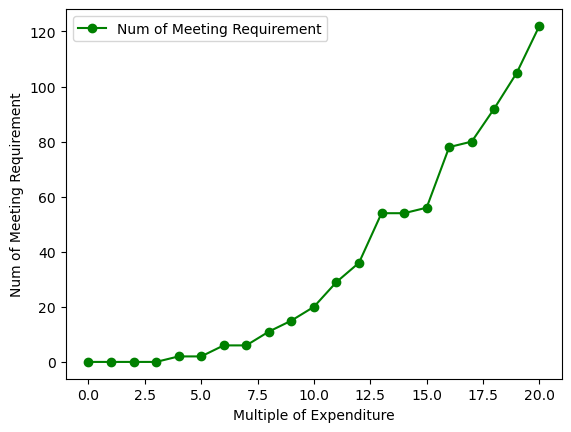

Total Number of People in the Dataset:  2198.0


In [9]:
graph_meeting_nutrients(FCT, Household_characteristics_2021, Food_Expenditure_2021_perday, Food_Prices_2021, Nutrient_requirement)

## Graph 3 and 4. Graph of Mutiple of Expenditure vs Num of Meeting Requirement for 2019-2020 and 2020-2021, grouped by region

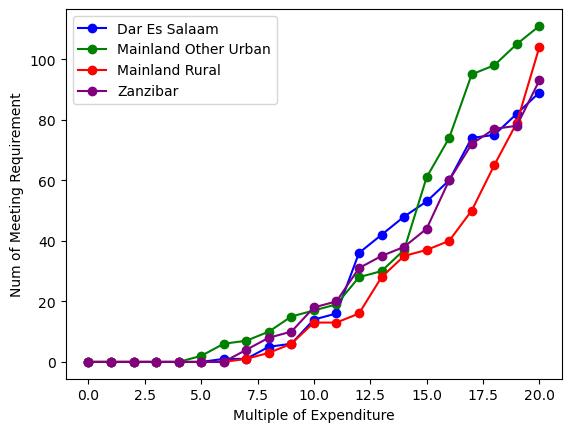

Total Number of People in the each region in the dataset: 
Dar Es Salaam :  630.0
Mainland Other Urban :  1223.0
Mainland Rural :  2953.0
Zanzibar :  628.0


In [10]:
list_of_regions = ['Dar Es Salaam','Mainland Other Urban','Mainland Rural','Zanzibar']

def graph_meeting_nutrients_by_region(FCT, Household_Characteristic, Expenditure, Food_Price, Requirement):

    meet_req_region = {"Multiple of Expenditure":list(range(21))}
    
    for j in list_of_regions:
        HC = Household_Characteristic[Household_Characteristic['m'] == j]
        multiples_of_expenditures = list(range(21))
        ttl_meet_requirement = []
        for i in multiples_of_expenditures:
            current = num_meet_requirement(FCT, HC, change_price(Expenditure, i), Food_Price, Requirement)
            ttl_meet_requirement.append(sum(current['meet_requirement']))
        meet_req_region[j] = ttl_meet_requirement

    df = pd.DataFrame(meet_req_region)
    
    df.plot(x="Multiple of Expenditure", y=list_of_regions, color=['blue', 'green', 'red', 'purple'], marker='o') #Assuming four regions
    plt.xlabel("Multiple of Expenditure")
    plt.ylabel("Num of Meeting Requirement")
    plt.show()
    print("Total Number of People in the each region in the dataset: ")
    for i in list_of_regions:
        print(i,": ", round(sum(avg_nutrient_household(FCT, Household_Characteristic[Household_Characteristic['m'] == i] , Expenditure, Food_Price)["HSize"]),0))

graph_meeting_nutrients_by_region(FCT, Household_characteristics_1920, Food_Expenditure_1920_perday, Food_Prices_1920, Nutrient_requirement)

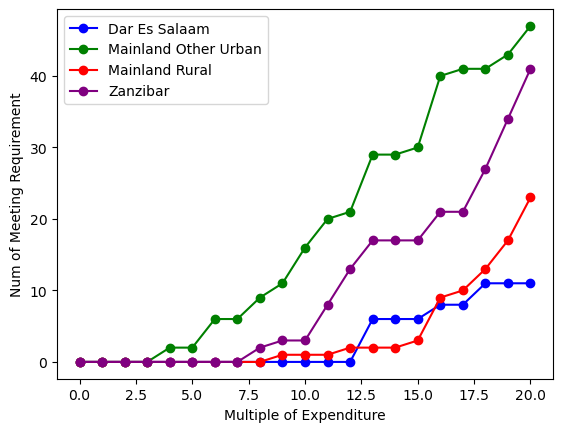

Total Number of People in the each region in the dataset: 
Dar Es Salaam :  235.0
Mainland Other Urban :  495.0
Mainland Rural :  1145.0
Zanzibar :  323.0


In [11]:
graph_meeting_nutrients_by_region(FCT, Household_characteristics_2021, Food_Expenditure_2021_perday, Food_Prices_2021, Nutrient_requirement)

## Graph 5 and 6. Graph of Multiple of Expenditure vs Num of Meeting Requirement for 2019-2020 and 2020-2021, grouped by region, by proportion

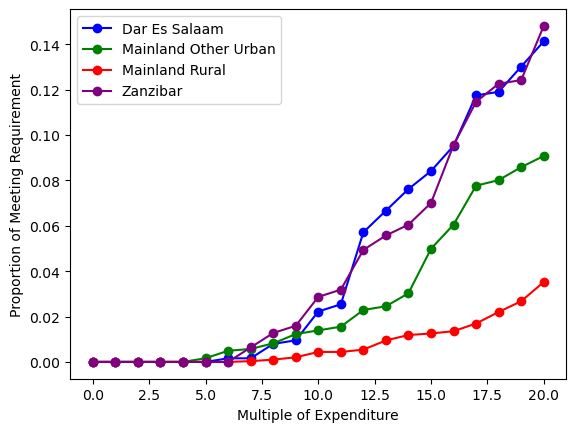

Total Number of People in the each region in the dataset: 
Dar Es Salaam :  630.0
Mainland Other Urban :  1223.0
Mainland Rural :  2953.0
Zanzibar :  628.0


In [17]:
list_of_regions = ['Dar Es Salaam','Mainland Other Urban','Mainland Rural','Zanzibar']

def graph_meeting_nutrients_by_region_p(FCT, Household_Characteristic, Expenditure, Food_Price, Requirement):

    meet_req_region = {"Multiple of Expenditure":list(range(21))}
    
    for j in list_of_regions:
        HC = Household_Characteristic[Household_Characteristic['m'] == j]
        multiples_of_expenditures = list(range(21))
        ttl_meet_requirement = []
        for i in multiples_of_expenditures:
            current = num_meet_requirement(FCT, HC, change_price(Expenditure, i), Food_Price, Requirement)
            ttl_meet_requirement.append(sum(current['meet_requirement']) / round(sum(avg_nutrient_household(FCT, HC , Expenditure, Food_Price)["HSize"]),0))
        meet_req_region[j] = ttl_meet_requirement

    df = pd.DataFrame(meet_req_region)
    
    df.plot(x="Multiple of Expenditure", y=list_of_regions, color=['blue', 'green', 'red', 'purple'], marker='o') #Assuming four regions
    plt.xlabel("Multiple of Expenditure")
    plt.ylabel("Proportion of Meeting Requirement")
    plt.show()
    print("Total Number of People in the each region in the dataset: ")
    for i in list_of_regions:
        print(i,": ", round(sum(avg_nutrient_household(FCT, Household_Characteristic[Household_Characteristic['m'] == i] , Expenditure, Food_Price)["HSize"]),0))

graph_meeting_nutrients_by_region_p(FCT, Household_characteristics_1920, Food_Expenditure_1920_perday, Food_Prices_1920, Nutrient_requirement)

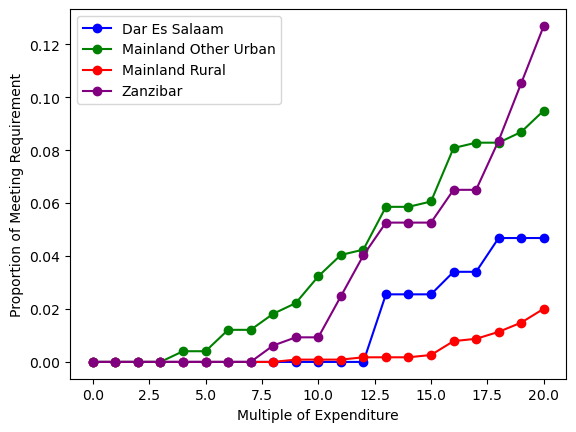

Total Number of People in the each region in the dataset: 
Dar Es Salaam :  235.0
Mainland Other Urban :  495.0
Mainland Rural :  1145.0
Zanzibar :  323.0


In [18]:
graph_meeting_nutrients_by_region_p(FCT, Household_characteristics_2021, Food_Expenditure_2021_perday, Food_Prices_2021, Nutrient_requirement)

## Graph 7 and 8. Graph of Multiple of Expenditure vs Num of Meeting Requirement for 2019-2020 and 2020-2021, grouped by household size, by proportion

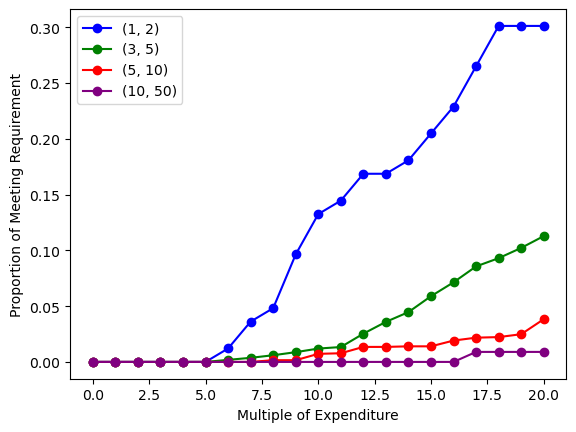

In [28]:
list_of_hsize = [(1,2),(3,5),(5,10),(10,50)]

def graph_meeting_nutrients_by_hsize_p(FCT, Household_Characteristic, Expenditure, Food_Price, Requirement):

    meet_req_region = {"Multiple of Expenditure":list(range(21))}

    H_C = Household_Characteristic.copy()
        
    H_C["HSize"] = np.exp(
        H_C["log HSize"]
        )

    
    for j in list_of_hsize:

        HC = H_C[(H_C['HSize'] >= j[0]) & (H_C['HSize'] <= j[1])]
        multiples_of_expenditures = list(range(21))
        ttl_meet_requirement = []
        
        for i in multiples_of_expenditures:
            current = num_meet_requirement(FCT, HC, change_price(Expenditure, i), Food_Price, Requirement)
            ttl_meet_requirement.append(sum(current['meet_requirement']) / round(sum(avg_nutrient_household(FCT, HC , Expenditure, Food_Price)["HSize"]),0))
        meet_req_region[j] = ttl_meet_requirement

    df = pd.DataFrame(meet_req_region)
    
    df.plot(x="Multiple of Expenditure", y=list_of_hsize, color=['blue', 'green', 'red', 'purple'], marker='o') #Assuming four regions
    plt.xlabel("Multiple of Expenditure")
    plt.ylabel("Proportion of Meeting Requirement")
    plt.show()

graph_meeting_nutrients_by_hsize_p(FCT, Household_characteristics_1920, Food_Expenditure_1920_perday, Food_Prices_1920, Nutrient_requirement)

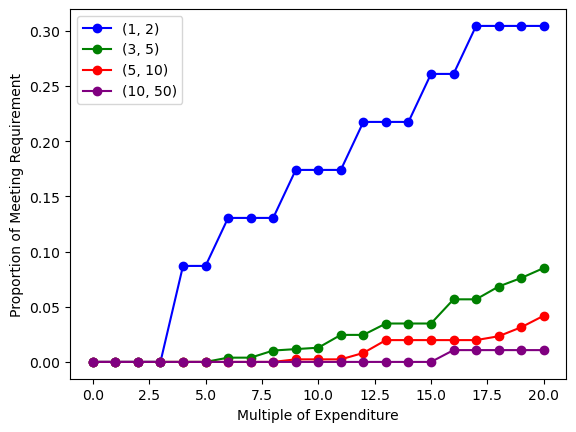

In [29]:
graph_meeting_nutrients_by_hsize_p(FCT, Household_characteristics_2021, Food_Expenditure_2021_perday, Food_Prices_2021, Nutrient_requirement)

## Graph 9 and 10. Graph of average nutrients compare to RDA of age groups in 2019-2020 and 2020-2021

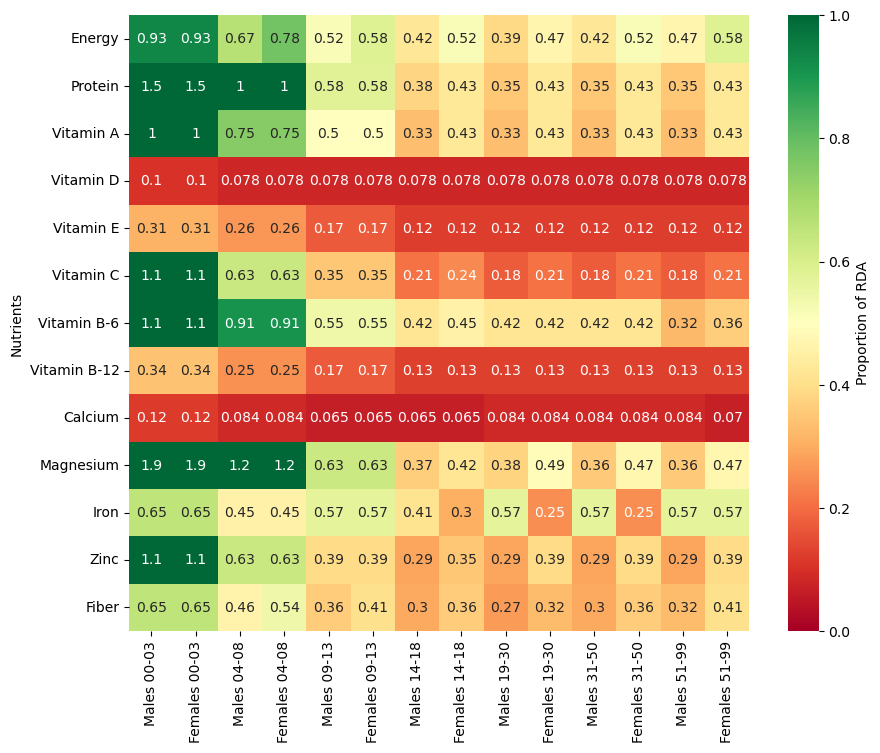

In [73]:

#Input the output create by the function avg_nutrient_household
def heat_map(avg, nutrient_req):
    age_sex_labels = nutrient_req.columns[1:].tolist()
    
    avg = avg.drop(columns=['i','HSize'])
    avg = avg.mean()
    avg_list = avg.tolist()
    
    
    nutrients = avg.index
    
    heatmap_df = {
        'Nutrients':['Energy','Protein','Vitamin A','Vitamin D','Vitamin E',
                     'Vitamin C','Vitamin B-6','Vitamin B-12',
                     'Calcium','Magnesium','Iron','Zinc','Fiber']
    }
    
    for i in age_sex_labels:
        prop = []
        for j in range(len(avg_list)):
            prop.append(avg_list[j] / nutrient_req[i][j])
        heatmap_df[i] = prop
  

    
    heatmap_df = pd.DataFrame(heatmap_df)
    
    heatmap_df.set_index('Nutrients', inplace=True)
    
    # Create the heatmap
    plt.figure(figsize=(10,8))
    sns.heatmap(heatmap_df, annot=True, cmap='RdYlGn', vmin=0,vmax=1,cbar_kws={'label': 'Proportion of RDA'})
    plt.ylabel('Nutrients')
    plt.show()


heat_map(avg_nutrient_household(FCT, Household_characteristics_1920, Food_Expenditure_1920_perday, Food_Prices_1920), Nutrient_requirement)

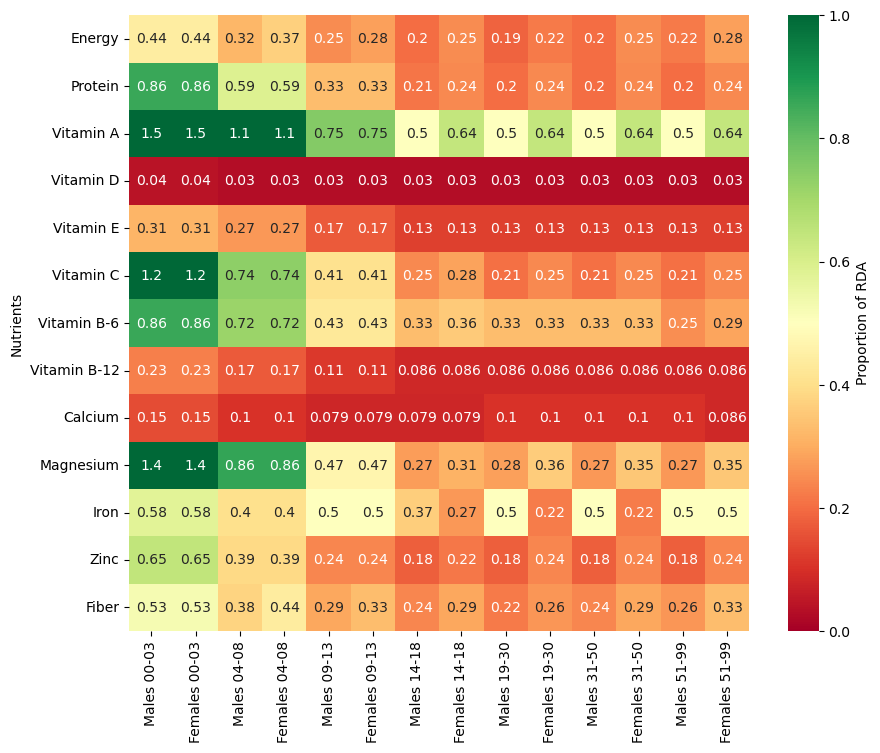

In [74]:
heat_map(avg_nutrient_household(FCT, Household_characteristics_2021, Food_Expenditure_2021_perday, Food_Prices_2021), Nutrient_requirement)